# 1️⃣ Dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdulrafeyyashir/fresh-vs-rotten-fruit-images")

print("Path to dataset files:", path)

100%|██████████| 38.5M/38.5M [00:00<00:00, 63.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/abdulrafeyyashir/fresh-vs-rotten-fruit-images/versions/4


- Check Dataset structure

In [ ]:
import os
def print_directory_structure(startpath):
    for root, dirs, files in os.walk(startpath): # Foldder , sub-folders , files
        level = root.replace(startpath, '').count(os.sep) # get the level of
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')

        # Print subdirectories
        subindent = ' ' * 4 * (level + 1)

        if files:
            print(f'{subindent}Contains {len(files)} files (e.g., {files[0]})')




In [ ]:
print_directory_structure(path)

fresh-vs-rotten-fruit-images/
    Contains 1 files (e.g., README.dataset.txt)
    Fruit Freshness Dataset/
        Fruit Freshness Dataset/
            Apple/
                Fresh/
                    Contains 124 files (e.g., apple_fresh_001.jpg (44).jpg)
                Rotten/
                    Contains 55 files (e.g., apple_rotten_001.jpg (37).jpg)
            Strawberry/
                Fresh/
                    Contains 220 files (e.g., strawberry_fresh_005.jpg (108).jpg)
                Rotten/
                    Contains 44 files (e.g., strawberry_rotten_005.jpg (15).jpg)
            Banana/
                Fresh/
                    Contains 33 files (e.g., banana_fresh_010 (9).jfif)
                Rotten/
                    Contains 90 files (e.g., banana_rotten_010.jpg (90).jpg)


- Here i will change the. structre of dataset to make it as follow

* Level 1 root folders
* Level 2 train and test folder
* Lever 3 the classes fresh and rotten contains the images

In [ ]:
import os
import shutil
import random

# Define the base path of the downloaded dataset
source_base_path = os.path.join(path, "Fruit Freshness Dataset", "Fruit Freshness Dataset")

# Define the target directory for the restructured dataset
target_dataset_path = "restructured_fruit_dataset"

# Define the train and test split ratio
train_split_ratio = 0.8

# Create the target directories
os.makedirs(os.path.join(target_dataset_path, "train", "fresh"), exist_ok=True)
os.makedirs(os.path.join(target_dataset_path, "train", "rotten"), exist_ok=True)
os.makedirs(os.path.join(target_dataset_path, "test", "fresh"), exist_ok=True)
os.makedirs(os.path.join(target_dataset_path, "test", "rotten"), exist_ok=True)

print(f"Created target directory structure at: {target_dataset_path}")

# List all fruit categories (Apple, Strawberry, Banana)
fruit_categories = [d for d in os.listdir(source_base_path) if os.path.isdir(os.path.join(source_base_path, d))]

for fruit_category in fruit_categories:
    print(f"\nProcessing fruit category: {fruit_category}")

    # Process 'fresh' images
    fresh_source_dir = os.path.join(source_base_path, fruit_category, "Fresh")
    if os.path.exists(fresh_source_dir):
        fresh_images = [f for f in os.listdir(fresh_source_dir) if os.path.isfile(os.path.join(fresh_source_dir, f))]
        random.shuffle(fresh_images) # Shuffle images for random split

        num_fresh_train = int(len(fresh_images) * train_split_ratio)
        fresh_train_images = fresh_images[:num_fresh_train]
        fresh_test_images = fresh_images[num_fresh_train:]

        for img in fresh_train_images:
            src_path = os.path.join(fresh_source_dir, img)
            dst_path = os.path.join(target_dataset_path, "train", "fresh", img)
            shutil.copy(src_path, dst_path) # Use copy to preserve original dataset
        print(f"Copied {len(fresh_train_images)} fresh images to train/fresh for {fruit_category}")

        for img in fresh_test_images:
            src_path = os.path.join(fresh_source_dir, img)
            dst_path = os.path.join(target_dataset_path, "test", "fresh", img)
            shutil.copy(src_path, dst_path)
        print(f"Copied {len(fresh_test_images)} fresh images to test/fresh for {fruit_category}")
    else:
        print(f"No 'Fresh' directory found for {fruit_category}")

    # Process 'rotten' images
    rotten_source_dir = os.path.join(source_base_path, fruit_category, "Rotten")
    if os.path.exists(rotten_source_dir):
        rotten_images = [f for f in os.listdir(rotten_source_dir) if os.path.isfile(os.path.join(rotten_source_dir, f))]
        random.shuffle(rotten_images) # Shuffle images for random split

        num_rotten_train = int(len(rotten_images) * train_split_ratio)
        rotten_train_images = rotten_images[:num_rotten_train]
        rotten_test_images = rotten_images[num_rotten_train:]

        for img in rotten_train_images:
            src_path = os.path.join(rotten_source_dir, img)
            dst_path = os.path.join(target_dataset_path, "train", "rotten", img)
            shutil.copy(src_path, dst_path)
        print(f"Copied {len(rotten_train_images)} rotten images to train/rotten for {fruit_category}")

        for img in rotten_test_images:
            src_path = os.path.join(rotten_source_dir, img)
            dst_path = os.path.join(target_dataset_path, "test", "rotten", img)
            shutil.copy(src_path, dst_path)
        print(f"Copied {len(rotten_test_images)} rotten images to test/rotten for {fruit_category}")
    else:
        print(f"No 'Rotten' directory found for {fruit_category}")





Created target directory structure at: restructured_fruit_dataset

Processing fruit category: Apple
Copied 99 fresh images to train/fresh for Apple
Copied 25 fresh images to test/fresh for Apple
Copied 44 rotten images to train/rotten for Apple
Copied 11 rotten images to test/rotten for Apple

Processing fruit category: Strawberry
Copied 176 fresh images to train/fresh for Strawberry
Copied 44 fresh images to test/fresh for Strawberry
Copied 35 rotten images to train/rotten for Strawberry
Copied 9 rotten images to test/rotten for Strawberry

Processing fruit category: Banana
Copied 26 fresh images to train/fresh for Banana
Copied 7 fresh images to test/fresh for Banana
Copied 72 rotten images to train/rotten for Banana
Copied 18 rotten images to test/rotten for Banana

Dataset restructuring complete. New dataset is located at: restructured_fruit_dataset

New dataset directory structure:
restructured_fruit_dataset/
    .ipynb_checkpoints/
    test/
        fresh/
            Contains 13

In [ ]:
print_directory_structure(target_dataset_path)

restructured_fruit_dataset/
    .ipynb_checkpoints/
    test/
        fresh/
            Contains 134 files (e.g., strawberry_fresh_005.jpg (123).jpg)
        rotten/
            Contains 69 files (e.g., banana_rotten_010.jpg (51).jpg)
    train/
        fresh/
            Contains 360 files (e.g., apple_fresh_001.jpg (13).jpg)
        rotten/
            Contains 182 files (e.g., banana_rotten_010.jpg (85).jpg)


In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import glob

class CustomDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir  # Dataset path
        self.transform = transform  # Transformations
        self.class_labels = {"fresh": 0, "rotten": 1}

        # Get all image paths
        self.image_paths = []
        self.labels = []
        for class_name, label in self.class_labels.items():
            class_images = glob.glob(f"{root_dir}/{class_name}/*.jpg")  # Find all images
            self.image_paths.extend(class_images)
            self.labels.extend([label] * len(class_images))  # Assign labels

    def __len__(self):
        return len(self.image_paths)  # Total number of images

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]  # Get image path
        label = self.labels[idx]  # Get label

        # Load image using PIL
        image = Image.open(image_path)

        # Apply transformations (if any)
        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
from torch.utils.data import DataLoader
import torchvision.transforms as transforms



train_path = os.path.join("restructured_fruit_dataset", "train")
test_path = os.path.join("restructured_fruit_dataset", "test")



transform = transforms.Compose([
    transforms.Resize((64, 64)),  # Resize images
    # transforms.RandomRotation(15),  # Rotate images randomly within ±15 degrees
    # transforms.ColorJitter(brightness=0.2),  # Adjust brightness randomly
    transforms.ToTensor(),  # Convert to tensor
    # transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),  # value for each channel
])

# Validation and testing data typically don’t require augmentations, as we only evaluate the model performance on these sets.
# Instead, we apply basic transformations to prepare the images.
transform_valid_test = transforms.Compose([
    transforms.Resize((64, 64)),  # Resize images to 64x64
    transforms.ToTensor(),  # Convert to tensor
    # transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),
])



train_dataset = CustomDataset(root_dir=train_path, transform=transform)
test_dataset = CustomDataset(root_dir=test_path, transform=transform)



batch_size = 32


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}, Labels: {labels}")

Batch shape: torch.Size([32, 3, 64, 64]), Labels: tensor([0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1,
        0, 0, 0, 0, 0, 0, 1, 1])


# 2️⃣ Model Class

In [ ]:
import torch.nn as nn
import torch

# Define the CNN Model
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # Convolutional Layers
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        # Activation
        self.relu = nn.ReLU()

        # Pooling Layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully Connected Layers
        # Corrected input features for fc1: 64 channels * 8x8 feature map size = 4096
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 2)  # Changed to 2 output classes for binary classification

    def forward(self, x):
        # Convolution + ReLU + Pooling
        x = self.pool(self.relu(self.conv1(x)))  # Output shape: (Batch, 16, 32, 32)
        x = self.pool(self.relu(self.conv2(x)))  # Output shape: (Batch, 32, 16, 16)
        x = self.pool(self.relu(self.conv3(x)))  # Output shape: (Batch, 64, 8, 8)

        # Flatten
        x = x.view(x.size(0), -1)  # Flattens to (Batch, 64 * 8 * 8 = 4096)

        # Fully Connected Layers
        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

# 3️⃣ Training and Validation Loops

In [ ]:
from tqdm import tqdm    # Shows progress bar

# 🔹 Training Loop
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()  # Set model to training mode
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader):
        images, labels = images.to(device), labels.to(device)


        outputs = model(images)  # Forward pass
        loss = criterion(outputs, labels)  # Compute loss

        optimizer.zero_grad()  # Reset gradients
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights

        total_loss += loss.item()

        # Track accuracy
        outputs = torch.softmax(outputs, dim=1) # [0.2 , 0.3 , 0.5]
        predictions = outputs.argmax(dim=1)  # Get class with highest probability [0 , 1 , 2] class 2
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total  # Compute accuracy in percentage
    return avg_loss, accuracy



# 🔹 Validation Loop
def validate(model, dataloader, criterion, device):
    model.eval()  # Set model to evaluation mode
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():  # Disable gradient computation
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            total_loss += loss.item()

            # Compute accuracy
            outputs = torch.softmax(outputs, dim=1)
            predictions = outputs.argmax(dim=1)  # Get predicted class
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total  # Compute accuracy in percentage
    return avg_loss, accuracy

# 4️⃣ Running Training

In [ ]:
import torch.optim as optim

# Initialize the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNModel().to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Multi-class Classification loss (Input: Logits, not probabilities)
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam optimizer
num_epochs = 10 # Number of epochs


# Lists to store metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Training process
for epoch in range(num_epochs):
    train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy = validate(model, test_loader, criterion, device)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss={train_loss:.4f}, Train Accuracy={train_accuracy:.2f}%, "
          f"Val Loss={val_loss:.4f}, Val Accuracy={val_accuracy:.2f}%")

100%|██████████| 16/16 [00:05<00:00,  2.87it/s]


Epoch 1/10: Train Loss=0.6228, Train Accuracy=65.66%, Val Loss=0.5621, Val Accuracy=72.63%


100%|██████████| 16/16 [00:04<00:00,  3.41it/s]


Epoch 2/10: Train Loss=0.4738, Train Accuracy=79.12%, Val Loss=0.3674, Val Accuracy=84.74%


100%|██████████| 16/16 [00:05<00:00,  2.93it/s]


...

Epoch 8/10: Train Loss=0.1958, Train Accuracy=91.97%, Val Loss=0.1579, Val Accuracy=94.21%


100%|██████████| 16/16 [00:05<00:00,  2.97it/s]


Epoch 9/10: Train Loss=0.2010, Train Accuracy=91.37%, Val Loss=0.1539, Val Accuracy=93.16%


100%|██████████| 16/16 [00:04<00:00,  3.56it/s]


Epoch 10/10: Train Loss=0.1612, Train Accuracy=92.97%, Val Loss=0.1195, Val Accuracy=95.26%


# 5 - Evalutaion

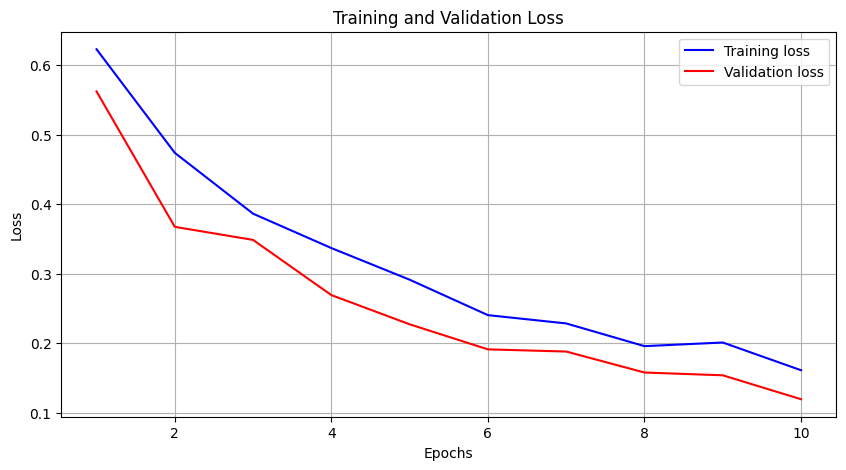

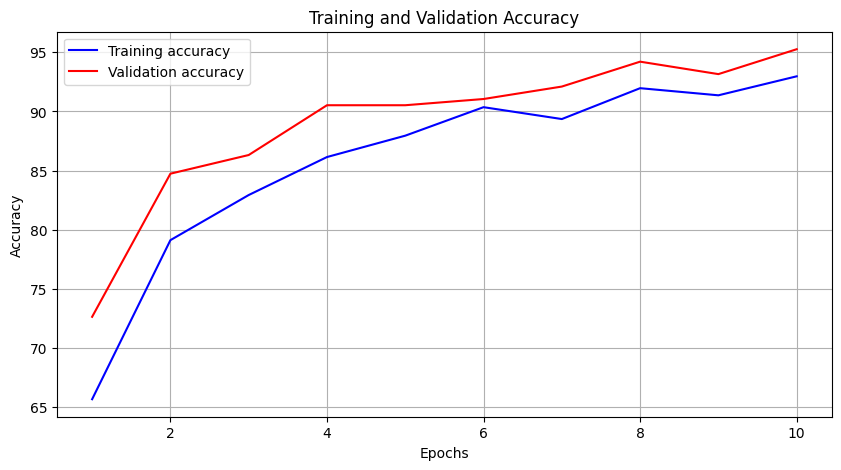

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

# Plotting Loss
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, 'b', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plotting Accuracy
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_accuracies, 'b', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Classification Report:
              precision    recall  f1-score   support

       fresh       0.98      0.94      0.96       122
      rotten       0.90      0.97      0.94        68

    accuracy                           0.95       190
   macro avg       0.94      0.96      0.95       190
weighted avg       0.95      0.95      0.95       190

Confusion Matrix:


<Figure size 800x600 with 0 Axes>

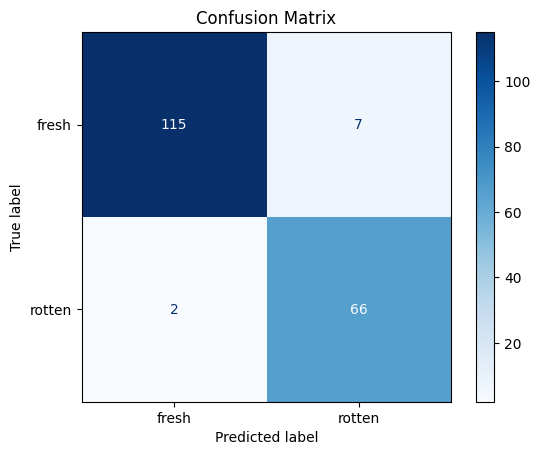

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Set the model to evaluation mode
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1) #_ value , Predicted index
        all_preds.extend(predicted.cpu().numpy()) # .extend() unrolls the batch and adds each individual prediction to the end of the master list.
        all_labels.extend(labels.cpu().numpy())

# Generate classification report
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=['fresh', 'rotten']))

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)
cmd = ConfusionMatrixDisplay(cm, display_labels=['fresh', 'rotten'])

print("Confusion Matrix:")
plt.figure(figsize=(8, 6))
cmd.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()